# Introducción

**HELP International** es una ONG humanitaria internacional dedicada a combatir la pobreza y brindar a las personas de países en desarrollo servicios básicos y ayuda humanitaria durante desastres y calamidades naturales. HELP International ha logrado recaudar alrededor de 10 millones de dólares. Este dinero ahora debe asignarse de manera estratégica y eficaz. Por lo tanto, para seleccionar los países que más necesitan ayuda, se deben tomar decisiones basadas en datos. Así, es necesario categorizar los países utilizando factores socioeconómicos y de salud que determinan su desarrollo general. De esta manera, con base en estos grupos de países según sus condiciones, se asignarán fondos para la asistencia durante desastres y calamidades naturales.

- **Objetivo:** Agrupar países según las diferentes características presentes

### DATASET

- **country:** Name of the country
- **child_mort:** Muerte de niños menores de 5 años por cada 1000 nacidos vivos
- **exports:** Exportaciones de bienes y servicios per cápita. Expresadas como porcentaje del PIB per cápita
- **health:** Gasto total en salud per cápita. Expresado como porcentaje del PIB per cápita
- **imports:** Importaciones de bienes y servicios per cápita. Expresadas como porcentaje del PIB per cápita
- **Income:** Ingreso neto por persona
- **Inflation:** Medida de la tasa de crecimiento anual del PIB total
- **life_expec:** Promedio de años que viviría un recién nacido si se mantuvieran los patrones de mortalidad actuales
- **total_fer:** Número de hijos que tendría cada mujer si se mantuvieran las tasas de fecundidad actuales
- **gdpp:** Calculado como el PIB total dividido por la población total

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import plotly.io as pio
import seaborn as sns
from ydata_profiling import ProfileReport
pd.options.display.float_format = '{:.2f}'.format
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.decomposition import PCA


# !pip install -U kaleido
import kaleido

In [2]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22']

In [3]:
data = pd.read_csv('data/Country-data.csv')
data.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200


In [4]:
data.shape

(167, 10)

In [5]:
data.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [7]:
data.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.79,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


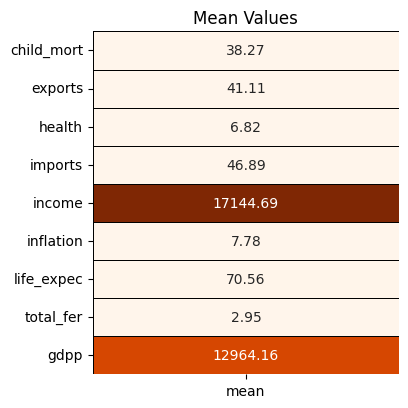

In [8]:
# Calculo de las Media de cada variable
fig,ax = plt.subplots(nrows = 1,ncols = 1,figsize = (5,5))

colors = ['#FF781F','#2D2926']
plt.subplot(1,1,1)
sns.heatmap(data.describe().T[['mean']],cmap = 'Oranges',annot = True,fmt = '.2f',linecolor = 'black',linewidths = 0.4,cbar = False);
plt.title('Mean Values');

fig.tight_layout(pad = 4)

In [9]:
#profile = ProfileReport(data, title="Análisis Exploratorio de Mi DataFrame")
#profile

# Análisis exploratorio de datos

In [10]:
# Visualizar columnas categóricas y numéricas
col = list(data.columns)
col.remove('country')
categorical_features = ['country']
numerical_features = [*col]
print('Categorical Features :',*categorical_features)
print('Numerical Features :',*numerical_features)

Categorical Features : country
Numerical Features : child_mort exports health imports income inflation life_expec total_fer gdpp


Claramente, a excepción del país, todas las características son numéricas, con sus elementos de tipo float o integer.

In [11]:
# Visualizar valores nulos
null_counts = data.isnull().sum()

# Filtramos para mostrar solo las columnas que SÍ tienen nulos (si las hubiera)
nulls_in_columns = null_counts[null_counts > 0]

if nulls_in_columns.empty:
    print("¡Confirmado! No hay valores nulos en ninguna columna.")
else:
    print("Columnas con valores nulos:")
    print(nulls_in_columns)

¡Confirmado! No hay valores nulos en ninguna columna.


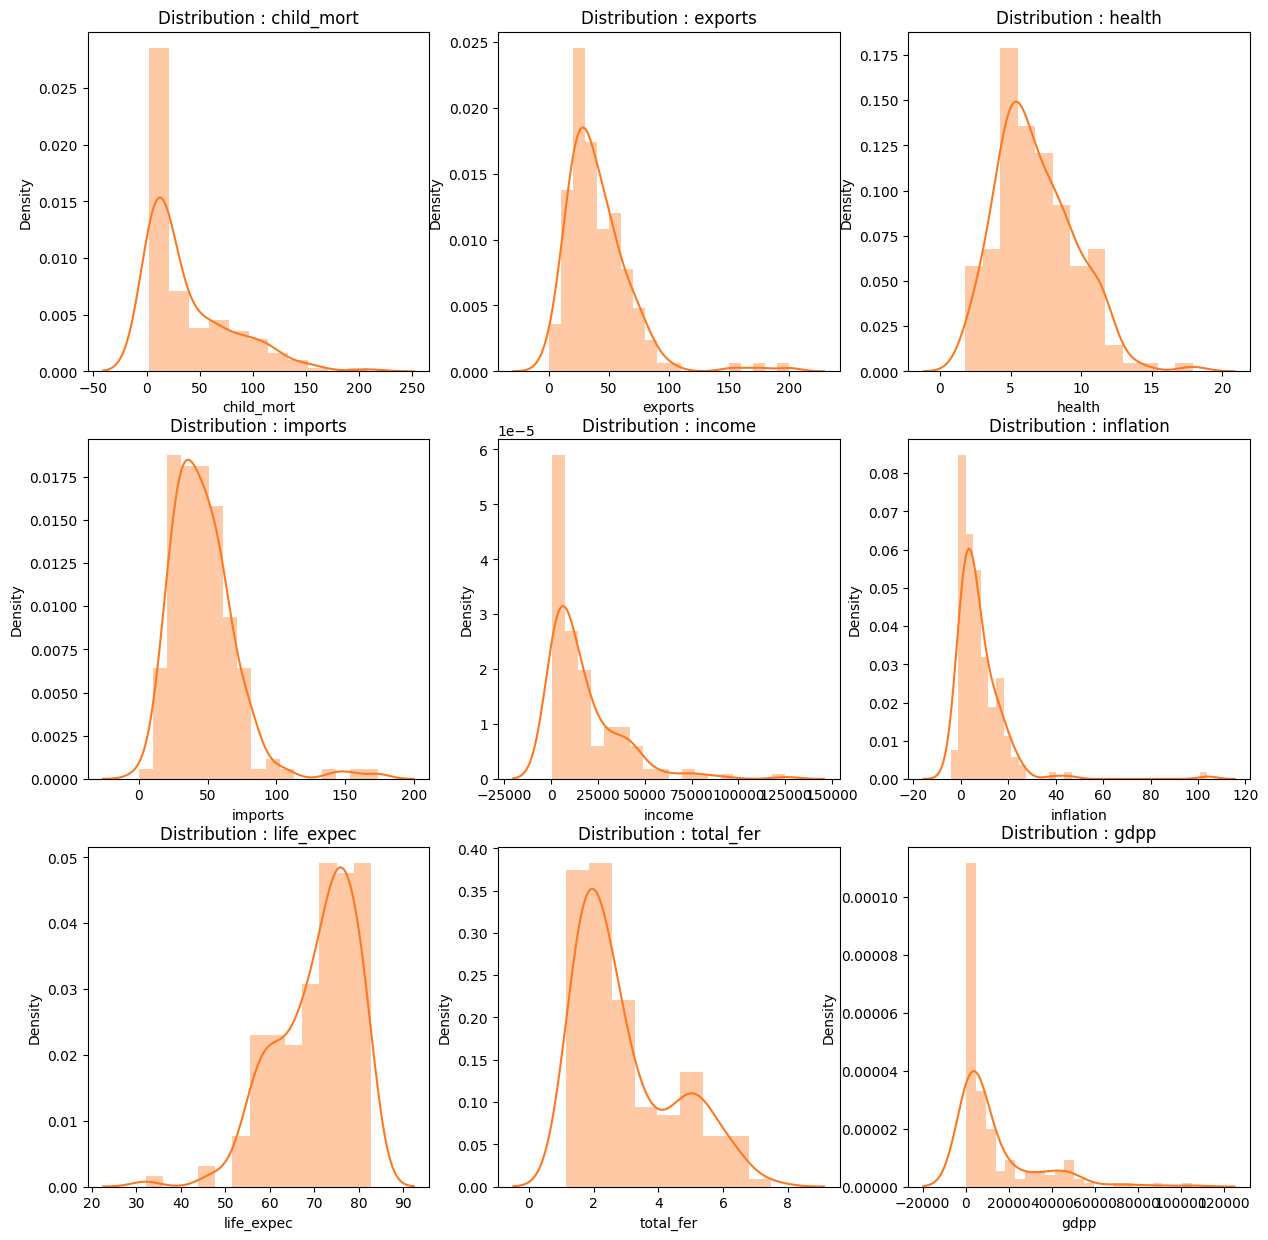

In [12]:
# Distribución de las variables numéricas
fig, ax = plt.subplots(nrows = 3,ncols = 3,figsize = (15,15))
for i in range(len(numerical_features)):
    plt.subplot(3,3,i+1)
    sns.distplot(data[numerical_features[i]],color = colors[0])
    title = 'Distribution : ' + numerical_features[i]
    plt.title(title)
plt.show()

- La variable `life_expec` muestra una distribución de datos asimétrica negativa (a la izquierda).

- La variable `health` muestra una distribución normal.

- Todas las demás variables muestran una distribución de datos asimétrica positiva (a la derecha).

In [13]:
# Comprobar valores repetidos
if len(data['country'].unique()) == len(data):
    print('No hay paises repetidos')

No hay paises repetidos


### Comparación de las variables numéricas vs country

**Características de los países económicamente atrasados:**

- El ingreso per cápita del país es muy bajo.
- Población elevada que conlleva escasez de recursos.
- Desempleo debido a la escasez de recursos.
- Baja riqueza nacional que resulta en escaso capital.
- Distribución inequitativa de la riqueza y los ingresos.
- Falta de infraestructura educativa adecuada, lo que provoca analfabetismo.
- Bajo nivel de vida.
- Escaso desarrollo tecnológico.
- Servicios de salud deficientes, junto con altas tasas de natalidad y mortalidad.

La **Fundación HELP** debe enfocarse en los países que presentan estas características. Visualizaremos los datos e identificaremos los países que se encuentran en los extremos y en el centro de cada característica para señalar los países que requieren asistencia.

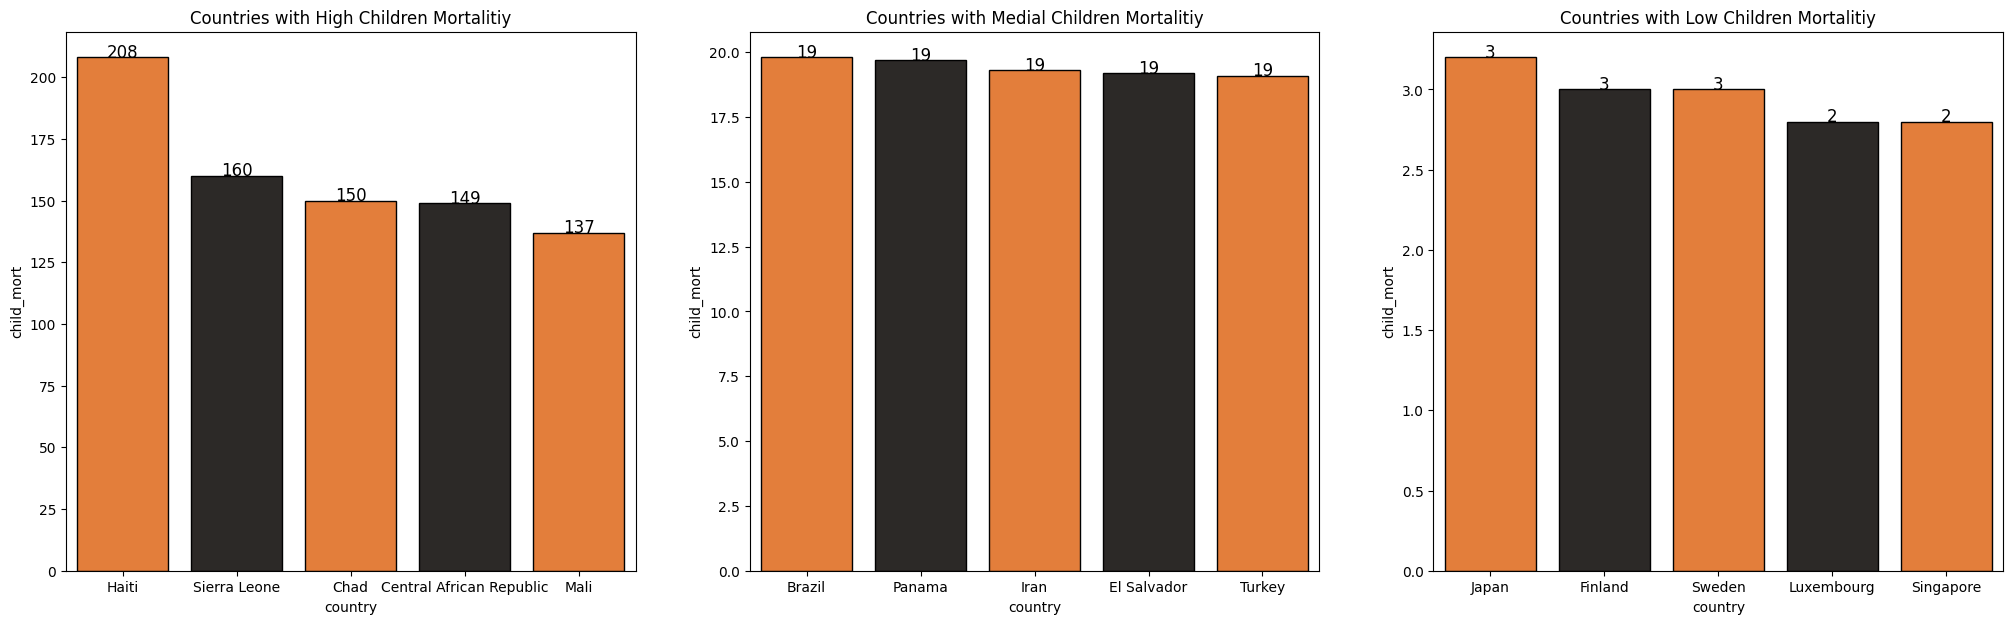

In [14]:
# child_mort: Los países económicamente atrasados ​​tienen una alta tasa de mortalidad infantil
fig = plt.subplots(nrows = 1,ncols = 3,figsize = (25,7))
plt.subplot(1,3,1)
ax = sns.barplot(x = 'country',y = 'child_mort', data = data.sort_values(ascending = False,by = 'child_mort').iloc[:5],palette = colors,edgecolor = 'black');
plt.title('Countries with High Children Mortalitiy')
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height(), int(rect.get_height()), 
            horizontalalignment='center', fontsize = 12)

plt.subplot(1,3,2)
ax = sns.barplot(x = 'country',y = 'child_mort', data = data.sort_values(ascending = False,by = 'child_mort').iloc[81:86],palette = colors,edgecolor = 'black');
plt.title('Countries with Medial Children Mortalitiy')
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height(), int(rect.get_height()), 
            horizontalalignment='center', fontsize = 12)

plt.subplot(1,3,3)
ax = sns.barplot(x = 'country',y = 'child_mort', data = data.sort_values(ascending = False,by = 'child_mort').iloc[161:166],palette = colors,edgecolor = 'black');
plt.title('Countries with Low Children Mortalitiy')
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height(), int(rect.get_height()), 
            horizontalalignment='center', fontsize = 12)
plt.show()

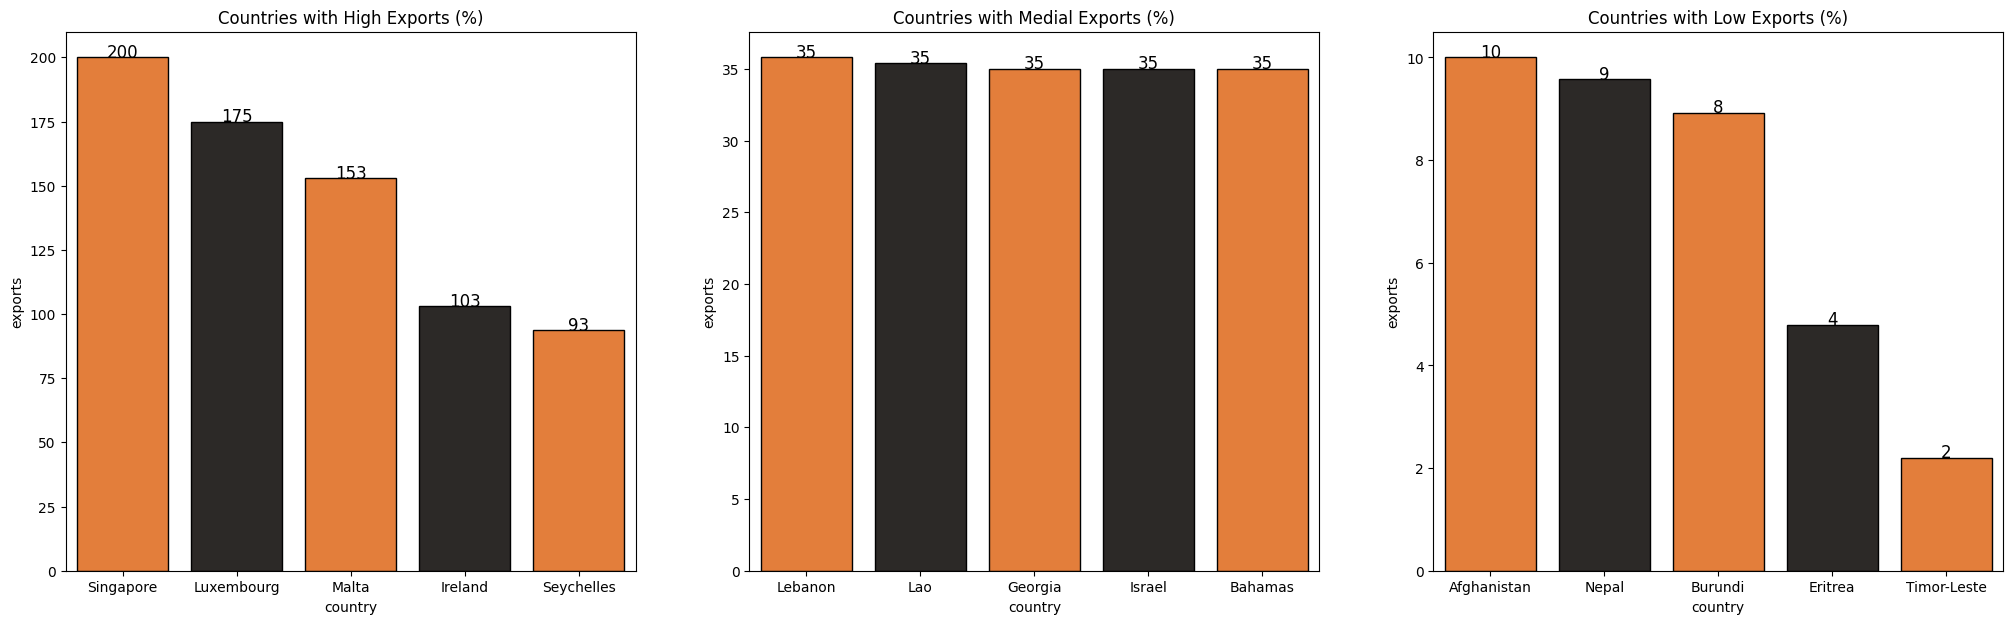

In [15]:
# exports: Es un factor muy importante para el desarrollo de la economía nacional. Cuanto mayores sean las exportaciones de una nación, más fuerte será su economía y mayor la riqueza que genere
fig = plt.subplots(nrows = 1,ncols = 3,figsize = (25,7))
plt.subplot(1,3,1)
ax = sns.barplot(x = 'country',y = 'exports', data = data.sort_values(ascending = False,by = 'exports').iloc[:5],palette = colors,edgecolor = 'black');
plt.title('Countries with High Exports (%)')
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height(), int(rect.get_height()), 
            horizontalalignment='center', fontsize = 12)

plt.subplot(1,3,2)
ax = sns.barplot(x = 'country',y = 'exports', data = data.sort_values(ascending = False,by = 'exports').iloc[81:86],palette = colors,edgecolor = 'black');
plt.title('Countries with Medial Exports (%)')
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height(), int(rect.get_height()), 
            horizontalalignment='center', fontsize = 12)

plt.subplot(1,3,3)
ax = sns.barplot(x = 'country',y = 'exports', data = data.sort_values(ascending = False,by = 'exports').iloc[161:166],palette = colors,edgecolor = 'black');
plt.title('Countries with Low Exports (%)')
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height(), int(rect.get_height()), 
            horizontalalignment='center', fontsize = 12)
plt.show()

In [16]:
# health: Los ciudadanos de los países desarrollados tienen mayores ingresos y, por lo tanto, no tienen problema en gastar más en un estilo de vida saludable.


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

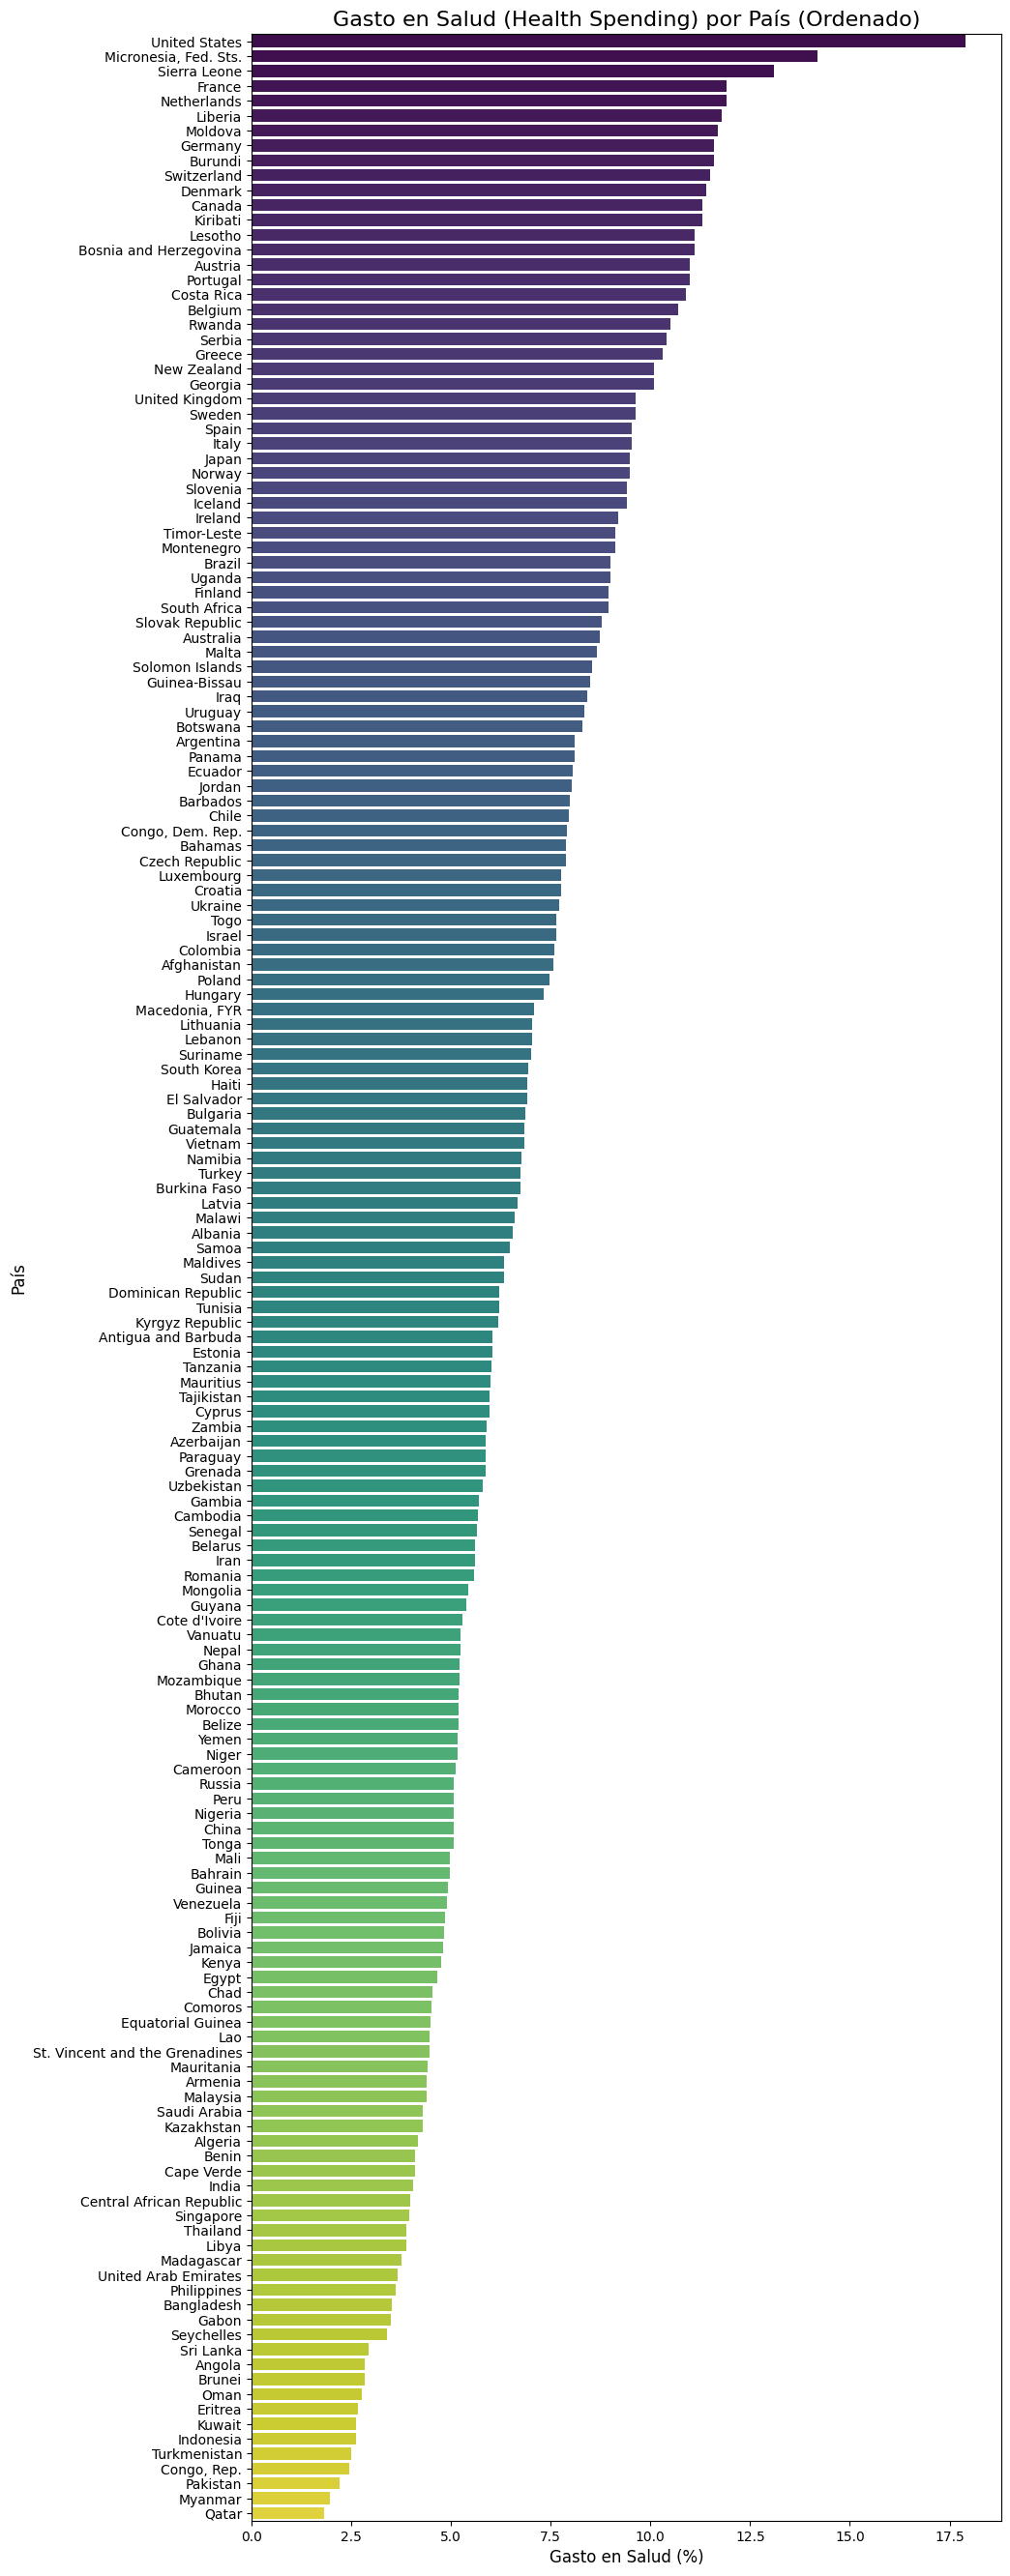

In [17]:
# health: Los ciudadanos de los países desarrollados tienen mayores ingresos y, por lo tanto, no tienen problema en gastar más en un estilo de vida saludable.
data_sorted = data.sort_values(by='health', ascending=False)

num_countries = len(data_sorted['country'].unique())
plot_height = max(10, num_countries * 0.2) 

plt.figure(figsize=(10, plot_height))


ax = sns.barplot(
    x='health',          
    y='country',         
    data=data_sorted,
    palette='viridis'   
)


plt.title('Gasto en Salud (Health Spending) por País (Ordenado)', fontsize=16)
plt.xlabel('Gasto en Salud (%)', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.tight_layout

### Características numéricas

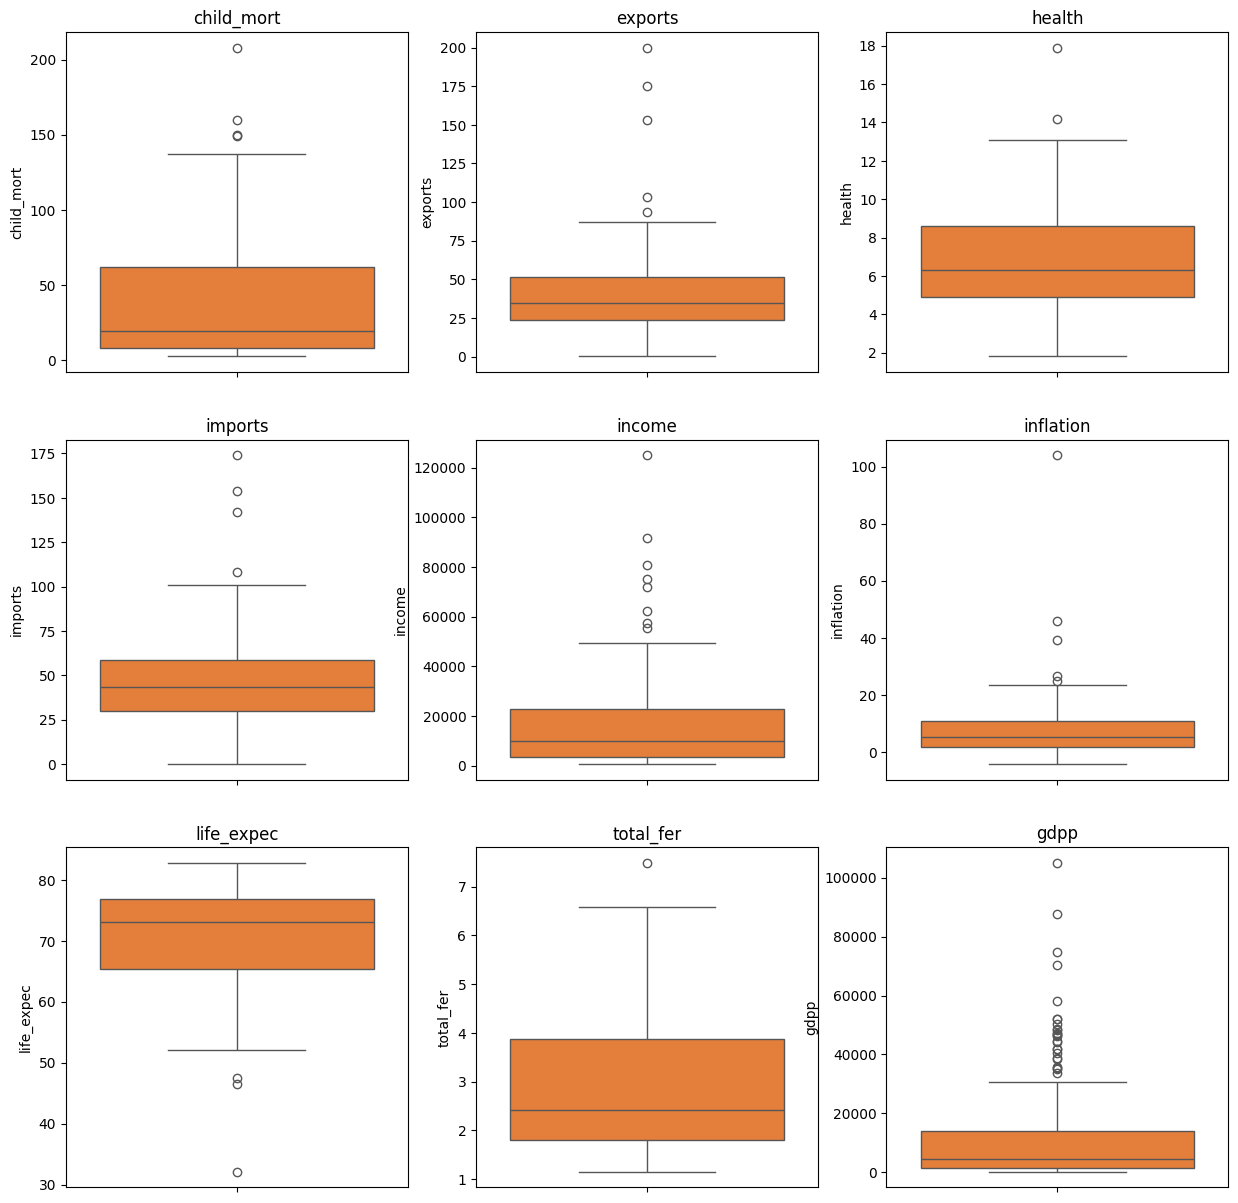

In [18]:
fig  = plt.subplots(nrows = 3,ncols = 3,figsize = (15,15))
for i in range(len(numerical_features)):
    plt.subplot(3,3,i+1)
    ax = sns.boxplot(data[numerical_features[i]],color = colors[0])
    plt.title(numerical_features[i])
plt.show()

### Resumen

A partir de las visualizaciones y la lista de características de las naciones económicamente atrasadas

- En cuanto a las condiciones de salud, los países africanos ocupan los primeros puestos en todos los aspectos negativos. Presentan una alta mortalidad infantil, baja esperanza de vida y alta mortalidad total.

- Todos estos problemas son bastante graves, por lo que es fundamental brindarles asistencia durante períodos de crisis imprevistas. A pesar de estas cifras, Haití ocupa el primer lugar con altos índices de mortalidad infantil. Los países asiáticos y europeos se encuentran en el extremo opuesto.

- Los ciudadanos estadounidenses son los que más gastan en salud; sin embargo, no figuran entre los cinco primeros en esperanza de vida ni en mortalidad total. Ninguno de los países con alta esperanza de vida se encuentra entre los cinco primeros en salud. Los países asiáticos se concentran en los últimos puestos en salud.

- Singapur, Malta, Luxemburgo y Seychelles figuran entre los cinco primeros en exportaciones e importaciones. El tamaño de la población y la ubicación geográfica desempeñan un papel fundamental en las importaciones y exportaciones. Sudán es el único país africano con bajas importaciones, y Brasil tiene las importaciones más bajas de todo el continente.

- Los países africanos presentan índices de inflación muy altos, mientras que en todos los continentes se encuentran países con baja inflación.

- Los ciudadanos de Qatar son los mejor pagados, con Singapur y Luxemburgo ocupando nuevamente los cinco primeros puestos en cuanto a ingresos.

- En cuanto al PIBP, Luxemburgo se encuentra entre los primeros. Suiza y Qatar también figuran entre los cinco primeros en términos de ingresos.

- Los países africanos se encuentran en la parte baja tanto en ingresos como en PIBP. La colonización ha tenido un impacto devastador en las naciones africanas.

# Ingeniería de variables

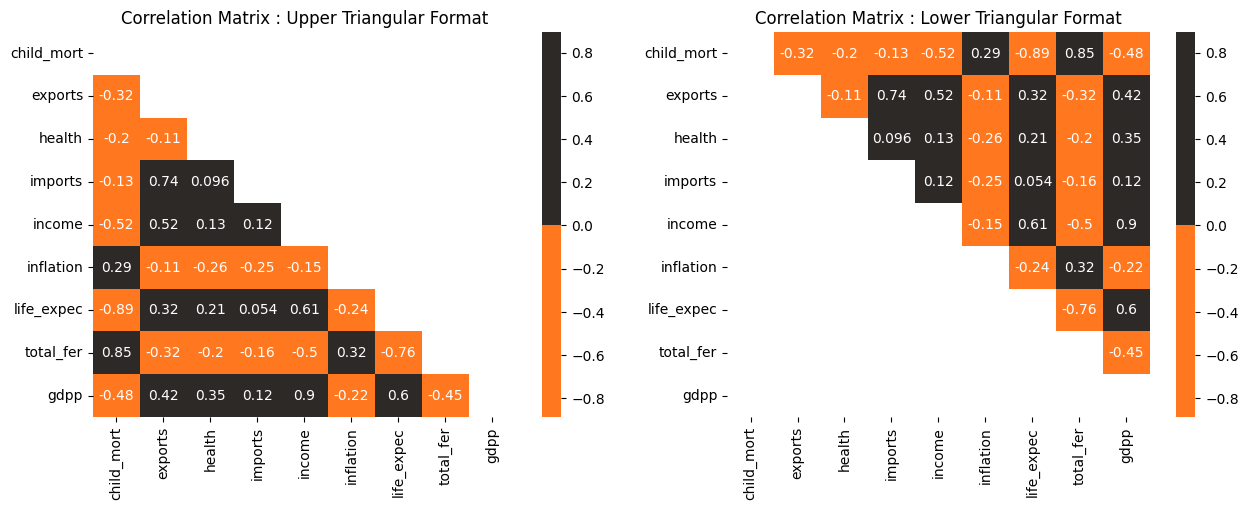

In [19]:
df_corr = data.drop(columns = 'country') 
ut = np.triu(df_corr.corr())
lt = np.tril(df_corr.corr())


fig,ax = plt.subplots(nrows = 1, ncols = 2,figsize = (15,5))
plt.subplot(1,2,1)
sns.heatmap(df_corr.corr(),cmap = colors,annot = True,cbar = 'True',mask = ut);
plt.title('Correlation Matrix : Upper Triangular Format');

plt.subplot(1,2,2)
sns.heatmap(df_corr.corr(),cmap = colors,annot = True,cbar = 'True',mask = lt);
plt.title('Correlation Matrix : Lower Triangular Format');

**Muchas variables están interrelacionadas**

- La mortalidad infantil aumenta claramente cuando disminuyen los ingresos, el PIB y las exportaciones. El aumento de la inflación también conlleva una alta mortalidad infantil. Lamentablemente, las condiciones económicas son un factor importante.

- El aumento de las exportaciones incrementa claramente el PIB, los ingresos y las importaciones.

- El gasto en salud produce un ligero aumento en la esperanza de vida y también disminuye la mortalidad infantil.

- Los ingresos y el PIB presentan una correlación muy alta de 0,9. Desde la perspectiva de la salud, los altos ingresos han llevado a una mayor esperanza de vida, pero disminuyen significativamente la mortalidad total.

- Como era de esperar, la alta inflación tiene un efecto negativo en las variables financieras. La alta inflación se traduce en una alta mortalidad total e infantil. Esto describe las características típicas de un país en vías de desarrollo.

- Según los datos, una mayor esperanza de vida se traduce en una baja mortalidad total. Un mayor PIB ha conllevado un mayor gasto en salud.

Podemos observar claramente que algunas variables pertenecen esencialmente a la misma categoría y reaccionan de la misma manera ante otras variables de categorías diferentes.

**Las tres categorías de las características son:**

- Salud: mortalidad infantil, salud, esperanza de vida, mortalidad total

- Comercio: importaciones, exportaciones

- Finanzas: ingresos, inflación, PIBP



In [20]:
df1 = pd.DataFrame()
df1['Health'] = (data['child_mort'] / data['child_mort'].mean()) + (data['health'] / data['health'].mean()) + (data['life_expec'] / data['life_expec'].mean()) + (data['total_fer'] / data['total_fer'].mean())
df1['Trade'] = (data['imports'] / data['imports'].mean()) + (data['exports'] / data['exports'].mean())
df1['Finance'] = (data['income'] / data['income'].mean()) + (data['inflation'] / data['inflation'].mean()) + (data['gdpp'] / data['gdpp'].mean())
df1.head()

,Health,Trade,Finance
0,6.24,1.20,1.35
1,3.04,1.72,1.47
2,3.39,1.60,3.17
3,6.47,2.43,3.49
4,2.96,2.36,2.24


### ESCALADO

In [21]:
mms = MinMaxScaler() # Normalization
ss = StandardScaler() # Standardization

df1['Health'] = mms.fit_transform(df1[['Health']])
df1['Trade'] = mms.fit_transform(df1[['Trade']])
df1['Finance'] = mms.fit_transform(df1[['Finance']])
df1.insert(loc = 0, value = list(data['country']), column = 'Country')
df1.head()

,Country,Health,Trade,Finance
0,Afghanistan,0.63,0.14,0.08
1,Albania,0.13,0.20,0.09
2,Algeria,0.18,0.19,0.21
3,Angola,0.66,0.28,0.24
4,Antigua and Barbuda,0.12,0.28,0.15


In [22]:
df2 = data.copy(deep = True)

col = list(data.columns)
col.remove('health')
col.remove('country')

df2['health'] = ss.fit_transform(df2[['health']]) # Standardization

for i in col:
    df2[i] = mms.fit_transform(df2[[i]]) # Normalization
df2.drop(columns = 'country',inplace = True) 
df2.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,0.43,0.05,0.28,0.26,0.01,0.13,0.48,0.74,0.00
1,0.07,0.14,-0.10,0.28,0.07,0.08,0.87,0.08,0.04
2,0.12,0.19,-0.97,0.18,0.10,0.19,0.88,0.27,0.04
3,0.57,0.31,-1.45,0.25,0.04,0.25,0.55,0.79,0.03
4,0.04,0.23,-0.29,0.34,0.15,0.05,0.88,0.15,0.11


### PCA

In [23]:
pca = PCA()
pca_df2 = pd.DataFrame(pca.fit_transform(df2))

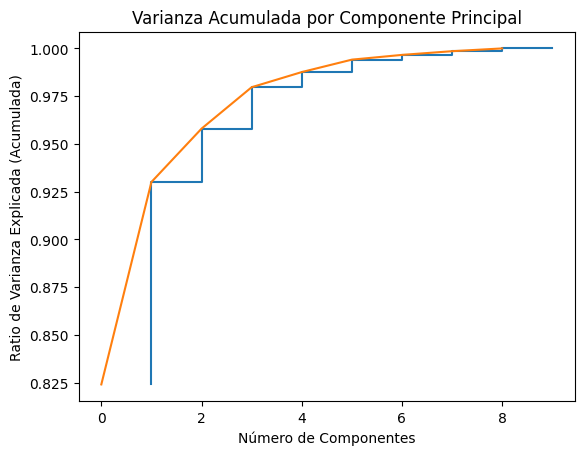

In [24]:
plt.step(list(range(1,10)), np.cumsum(pca.explained_variance_ratio_))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Número de Componentes')
plt.ylabel('Ratio de Varianza Explicada (Acumulada)')
plt.title('Varianza Acumulada por Componente Principal')
plt.show()

**Conclusiones PCA**

- Este es un método muy eficaz donde sumamos las varianzas de todas las características de forma acumulativa.

- En este caso, seleccionamos tres componentes principales, ya que los pasos generados presentan varianzas significativas y, por lo tanto, las varianzas de las demás características se ven eclipsadas por ellas.

In [25]:
pca_df2 = pca_df2.drop(columns = [3,4,5,6,7,8])
pca_df2.head()

,0,1,2
0,0.22,0.64,0.09
1,-0.08,-0.17,-0.21
2,-0.96,-0.13,-0.13
3,-1.51,0.47,0.28
4,-0.26,-0.24,-0.06


# MODELADO

## CASO 1: Health - Trade - Finance

In [26]:
m1 = df1.drop(columns = ['Country']).values
df1_aux = df1.drop(columns = ['Country'])
df1_aux.head()

,Health,Trade,Finance
0,0.63,0.14,0.08
1,0.13,0.20,0.09
2,0.18,0.19,0.21
3,0.66,0.28,0.24
4,0.12,0.28,0.15


**Hiperparámetro k:** Define el número de clústeres o grupos en los que se dividen los datos. Para la selección de valores de k, utilizamos dos pruebas estadísticas:

**Método del Codo:** Este método grafica la suma de los errores al cuadrado para un rango de valores de k. Si la gráfica resultante se asemeja a un brazo, se selecciona el valor de k que más se asemeja a un codo. A partir de este valor, la suma de los errores al cuadrado (inercia) comienza a disminuir linealmente y, por lo tanto, se considera un valor óptimo.

**Método de la Puntuación de Silueta:** Este método evalúa la calidad de los clústeres en función de la similitud entre los puntos de datos. Esta puntuación se calcula mediante la fórmula de distancia y se selecciona el valor de k con la puntuación más alta para el modelado.

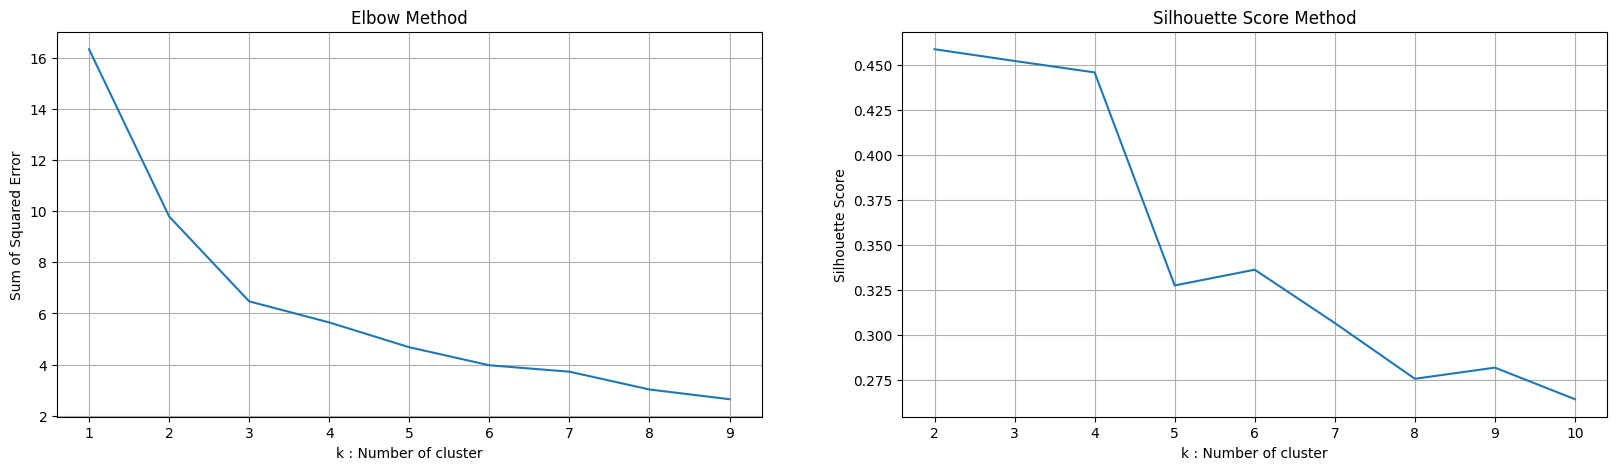

In [27]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")
plt.grid()

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.grid()

plt.show()

### k-means

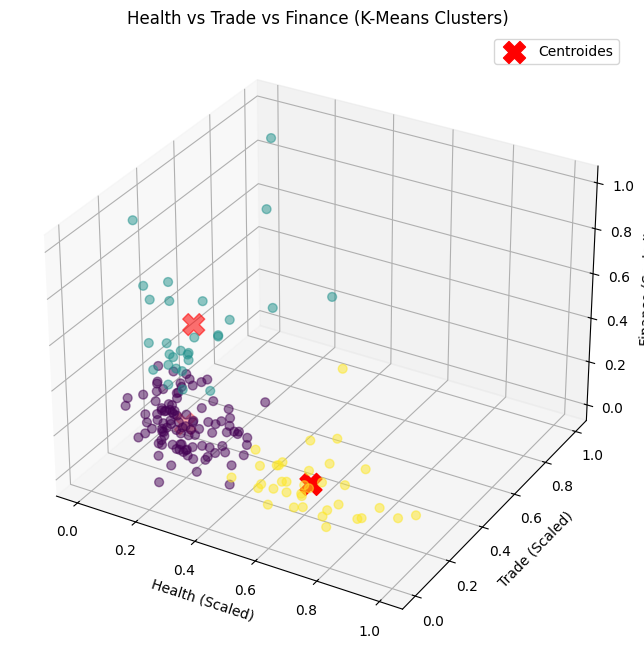

In [28]:
model = KMeans(n_clusters = 3, max_iter = 1000, n_init='auto', random_state=42) # Añadido n_init y random_state
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_
data['Class'] = labels
df1['Class'] = labels

# --- GRÁFICO 3D (Corregido) ---
fig = plt.figure(figsize=(10, 8))
# CORRECCIÓN 3: Usar el método moderno para crear el eje 3D
ax = fig.add_subplot(111, projection='3d')

x = np.array(df1['Health'])
y = np.array(df1['Trade'])
z = np.array(df1['Finance'])

# Dibujar los centroides (en la misma escala 0-1)
ax.scatter(centroids[:,0],centroids[:,1],centroids[:,2], marker="X", color = 'red', s=250, label='Centroides')
ax.scatter(x,y,z, c=labels, cmap='viridis', s=40, alpha=0.5)
plt.title('Health vs Trade vs Finance (K-Means Clusters)')
ax.set_xlabel('Health (Scaled)')
ax.set_ylabel('Trade (Scaled)')
ax.set_zlabel('Finance (Scaled)')
ax.legend()
plt.show();

In [29]:
### Métrica de silhouette

silhouette_avg = silhouette_score(m1, labels)
print(f"El Silhouette Score promedio es: {silhouette_avg:.4f}")

El Silhouette Score promedio es: 0.4520


**Sabemos que los bajos ingresos y la alta mortalidad infantil son un signo de una nación económicamente atrasada.**

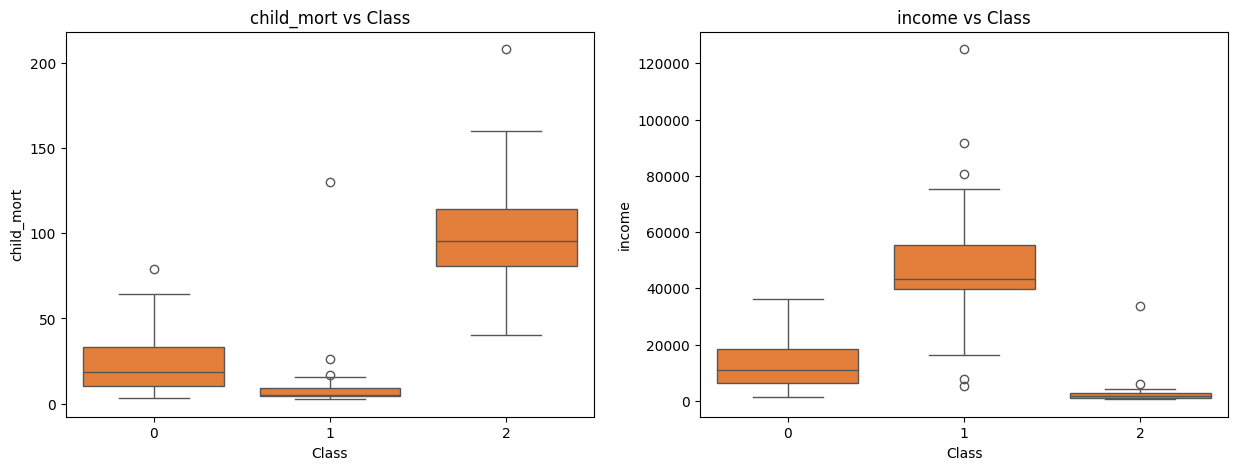

In [30]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (15,5))

plt.subplot(1,2,1)
sns.boxplot(x = 'Class', y = 'child_mort', data  = data, color = '#FF781F');
plt.title('child_mort vs Class')

plt.subplot(1,2,2)
sns.boxplot(x = 'Class', y = 'income', data  = data, color = '#FF781F');
plt.title('income vs Class')

plt.show()

In [31]:
label_map = {
    0: 'Might Need Help',
    1: 'No Help Needed',
    2: 'Help Needed'
}
# Creamos una nueva columna para la etiqueta
df1['Class_Label'] = df1['Class'].map(label_map)

fig = px.choropleth(
    df1, 
    locationmode = 'country names',
    locations = 'Country',
    title = 'Needed Help Per Country (World)',
    color = 'Class_Label',
    color_discrete_map = {
        'Help Needed':'Red',
        'No Help Needed':'Green',
        'Might Need Help':'Yellow'
    }
)
fig.update_geos(fitbounds = "locations", visible = True)
fig.update_layout(legend_title_text = 'Labels',legend_title_side = 'top',title_pad_l = 260,title_y = 0.86)

# Establece el renderizador por defecto para que funcione en entornos de notebook
pio.renderers.default = "notebook_connected"
fig.show()

### CASO 2: PCA Variables

In [32]:
m2 = pca_df2.values
pca_df2.head()

,0,1,2
0,0.22,0.64,0.09
1,-0.08,-0.17,-0.21
2,-0.96,-0.13,-0.13
3,-1.51,0.47,0.28
4,-0.26,-0.24,-0.06


**Hiperparámetro k:** Define el número de clústeres o grupos en los que se dividen los datos. Para la selección de valores de k, utilizamos dos pruebas estadísticas:

**Método del Codo:** Este método grafica la suma de los errores al cuadrado para un rango de valores de k. Si la gráfica resultante se asemeja a un brazo, se selecciona el valor de k que más se asemeja a un codo. A partir de este valor, la suma de los errores al cuadrado (inercia) comienza a disminuir linealmente y, por lo tanto, se considera un valor óptimo.

**Método de la Puntuación de Silueta:** Este método evalúa la calidad de los clústeres en función de la similitud entre los puntos de datos. Esta puntuación se calcula mediante la fórmula de distancia y se selecciona el valor de k con la puntuación más alta para el modelado.

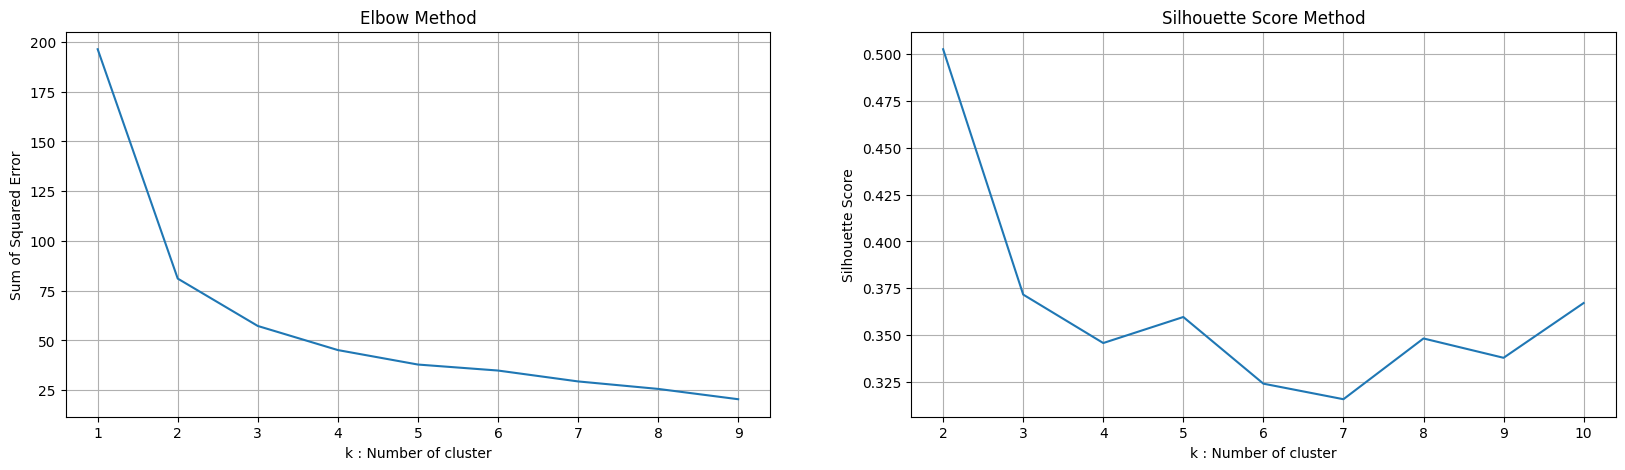

In [33]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")
plt.grid()

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.grid()

plt.show()

### k-means

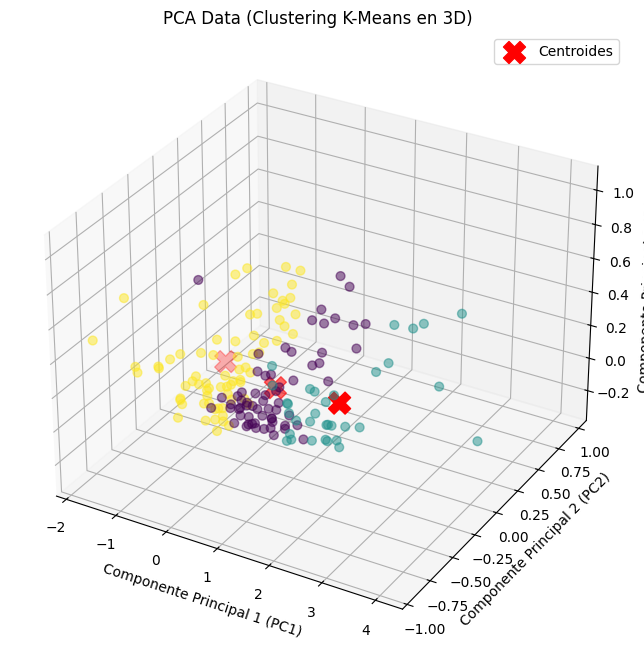

In [34]:
model = KMeans(n_clusters = 3, max_iter = 1000, n_init='auto', random_state=42)
model.fit(m2)

# Obtenemos los centroides (están en la escala PCA)
centroids = model.cluster_centers_
labels = model.labels_
pca_df2['Class'] = labels
data['Class']= labels


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
x = m2[:, 0]
y = m2[:, 1]
z = m2[:, 2]
ax.scatter(x, y, z, c=labels, cmap='viridis', s=40, alpha=0.5)
ax.scatter(centroids[:,0], centroids[:,1], centroids[:,2], 
           marker="X", color='red', s=250, label='Centroides')

plt.title('PCA Data (Clustering K-Means en 3D)')
ax.set_xlabel('Componente Principal 1 (PC1)')
ax.set_ylabel('Componente Principal 2 (PC2)')
ax.set_zlabel('Componente Principal 3 (PC3)')
ax.legend()
plt.show();

In [35]:
### Métrica de silhouette

silhouette_avg = silhouette_score(m2, labels)
print(f"El Silhouette Score promedio es: {silhouette_avg:.4f}")

El Silhouette Score promedio es: 0.3887


**Sabemos que los bajos ingresos y la alta mortalidad infantil son un signo de una nación económicamente atrasada.**

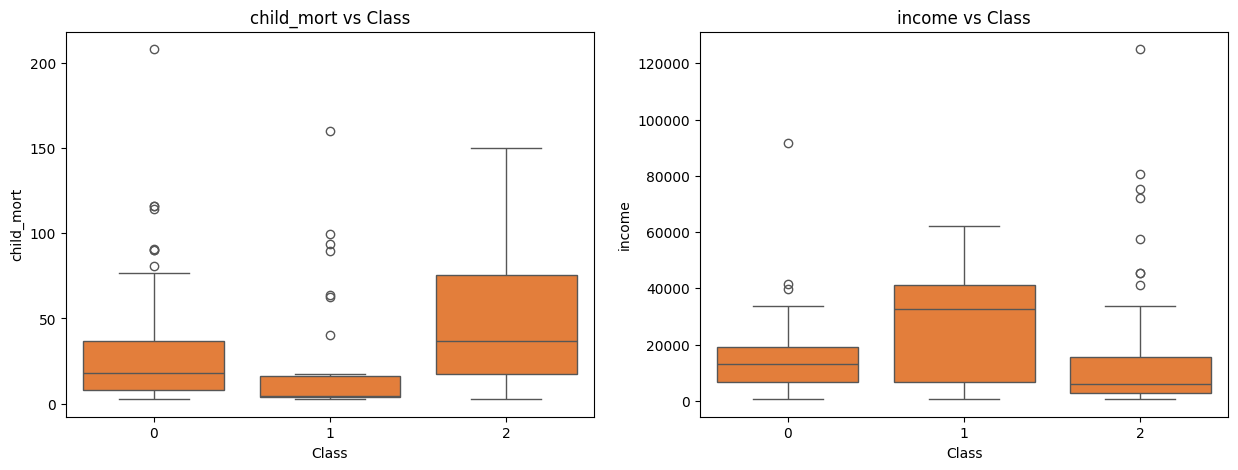

In [36]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (15,5))

plt.subplot(1,2,1)
sns.boxplot(x = 'Class', y = 'child_mort', data  = data, color = '#FF781F');
plt.title('child_mort vs Class')

plt.subplot(1,2,2)
sns.boxplot(x = 'Class', y = 'income', data  = data, color = '#FF781F');
plt.title('income vs Class')

plt.show()

In [37]:
label_map = {
    0: 'Might Need Help',
    1: 'No Help Needed',
    2: 'Help Needed'
}
# Creamos una nueva columna para la etiqueta
pca_df2['Country'] = data['country']
pca_df2['Class_Label'] = pca_df2['Class'].map(label_map)

fig = px.choropleth(
    pca_df2, 
    locationmode = 'country names',
    locations = 'Country',
    title = 'Needed Help Per Country (World)',
    color = 'Class_Label', 
    color_discrete_map = {
        'Help Needed':'Red',
        'No Help Needed':'Green',
        'Might Need Help':'Yellow'
    }
)
fig.update_geos(fitbounds = "locations", visible = True)
fig.update_layout(legend_title_text = 'Labels',legend_title_side = 'top',title_pad_l = 260,title_y = 0.86)

# Establece el renderizador por defecto para que funcione en entornos de notebook
pio.renderers.default = "notebook_connected"
fig.show()

### CASO 3: Todas las variables

In [38]:
# ESCALADO
country_names = data['country']

# Crear el DataFrame para escalar (quitando la columna no numérica 'Country')
data_to_scale = data.drop(columns=['country', 'Class'])
# Inicializar el escalador
scaler = StandardScaler()
# Escalar todas las columnas numéricas
scaled_data_array = scaler.fit_transform(data_to_scale)
# Crear un nuevo DataFrame escalado con los nombres de columna
scaled_df = pd.DataFrame(scaled_data_array, columns=data_to_scale.columns)
scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.29,-1.14,0.28,-0.08,-0.81,0.16,-1.62,1.90,-0.68
1,-0.54,-0.48,-0.10,0.07,-0.38,-0.31,0.65,-0.86,-0.49
2,-0.27,-0.10,-0.97,-0.64,-0.22,0.79,0.67,-0.04,-0.47
3,2.01,0.78,-1.45,-0.17,-0.59,1.39,-1.18,2.13,-0.52
4,-0.70,0.16,-0.29,0.50,0.10,-0.60,0.70,-0.54,-0.04


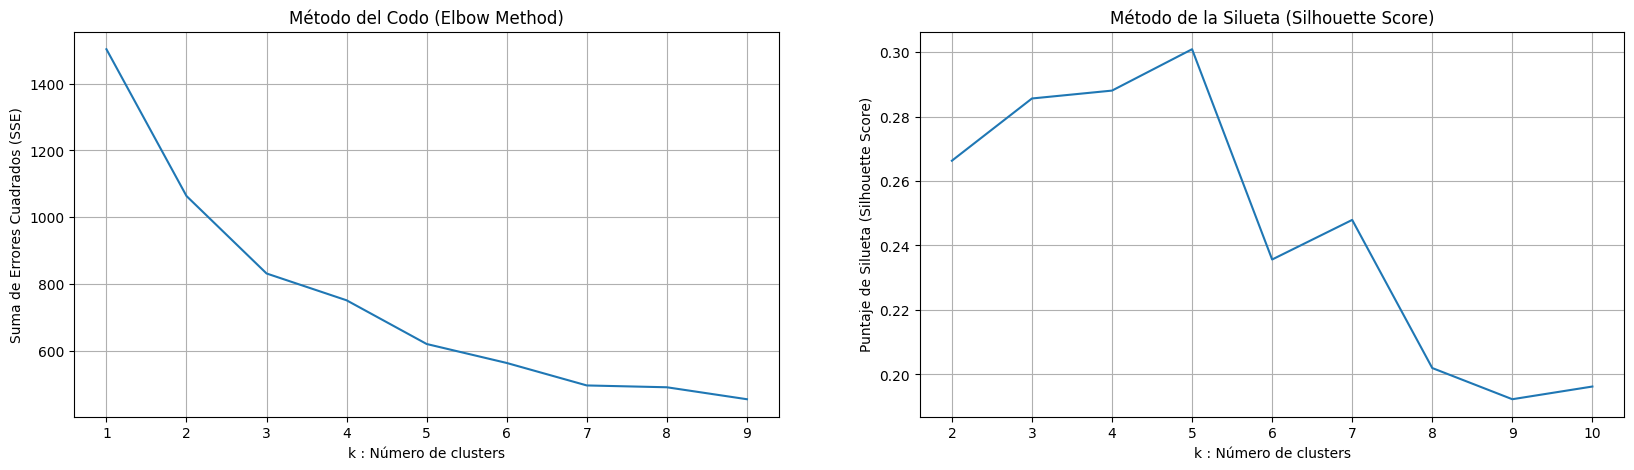

In [39]:
# Encontrar 'k' (Codo y Silueta) ---

sse = {}; sil = []; kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Método del Codo (Elbow)
plt.subplot(1,2,1)
for k in range(1, kmax): # kmax en lugar de 10
    kmeans = KMeans(n_clusters=k, max_iter=1000, n_init='auto', random_state=42).fit(scaled_data_array)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Método del Codo (Elbow Method)')
plt.xlabel("k : Número de clusters")
plt.ylabel("Suma de Errores Cuadrados (SSE)")
plt.grid()

# Método de la Silueta (Silhouette)
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k, n_init='auto', random_state=42).fit(scaled_data_array)
    labels = kmeans.labels_
    sil.append(silhouette_score(scaled_data_array, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Método de la Silueta (Silhouette Score)')
plt.xlabel("k : Número de clusters")
plt.ylabel("Puntaje de Silueta (Silhouette Score)")
plt.grid()

plt.show()

In [40]:
# K-MEANS 

# Asumiremos k basado en los gráficos típicos de este dataset
k_final = 5
model = KMeans(n_clusters = k_final, max_iter = 1000, n_init='auto', random_state=42)
model.fit(scaled_data_array)
labels = model.labels_
centroids = model.cluster_centers_

scaled_df['Class'] = labels
scaled_df['Country'] = country_names
data['Class'] = labels

# Contar los valores en la columna 'Class' y ordenar por el número de cluster
cluster_counts = data['Class'].value_counts().sort_index()
print("Cantidad de puntos (países) por cluster:")
print(cluster_counts)

Cantidad de puntos (países) por cluster:
Class
0    87
1    32
2    44
3     1
4     3
Name: count, dtype: int64


In [41]:
### Métrica de silhouette

silhouette_avg = silhouette_score(scaled_data_array, labels)
print(f"El Silhouette Score promedio es: {silhouette_avg:.4f}")

El Silhouette Score promedio es: 0.3009


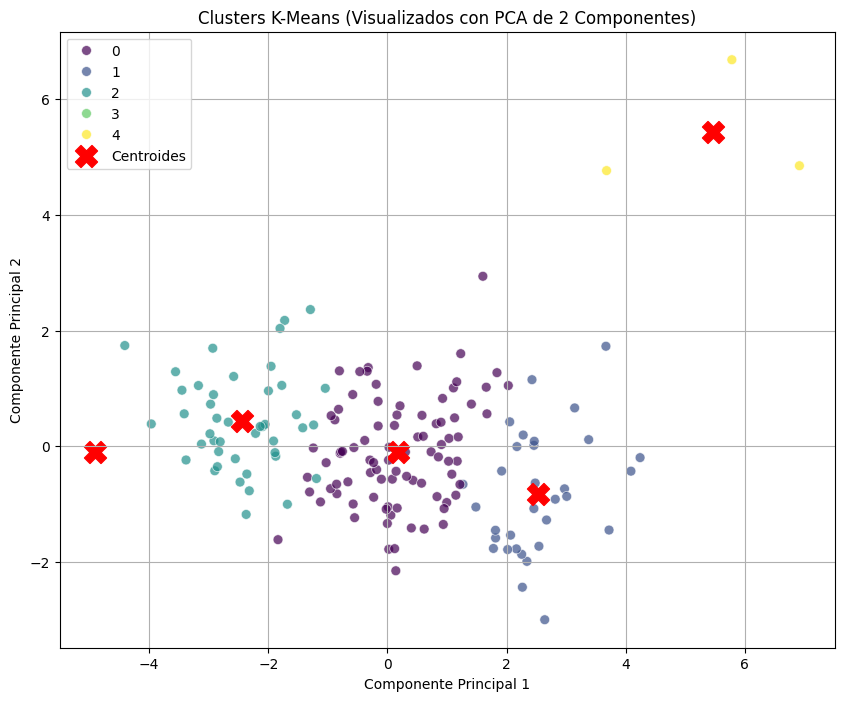

In [42]:
# VISUALIZACIÓN

from sklearn.decomposition import PCA

# --- 1. Aplicar PCA (con 2 componentes) ---
pca_2d = PCA(n_components=2)
data_pca_2d = pca_2d.fit_transform(scaled_data_array)
centroids_pca_2d = pca_2d.transform(centroids)

# Crear un DataFrame para graficar
pca_df_2d = pd.DataFrame(data_pca_2d, columns=['PC1', 'PC2'])
pca_df_2d['Class'] = labels



fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(
    data=pca_df_2d, 
    x='PC1', 
    y='PC2', 
    hue='Class', 
    palette='viridis', 
    alpha=0.7, 
    s=50,
    ax=ax
)
ax.scatter(
    centroids_pca_2d[:, 0], 
    centroids_pca_2d[:, 1], 
    marker='X', 
    color='red', 
    s=250, 
    label='Centroides'
)

plt.title('Clusters K-Means (Visualizados con PCA de 2 Componentes)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(True)
plt.show()

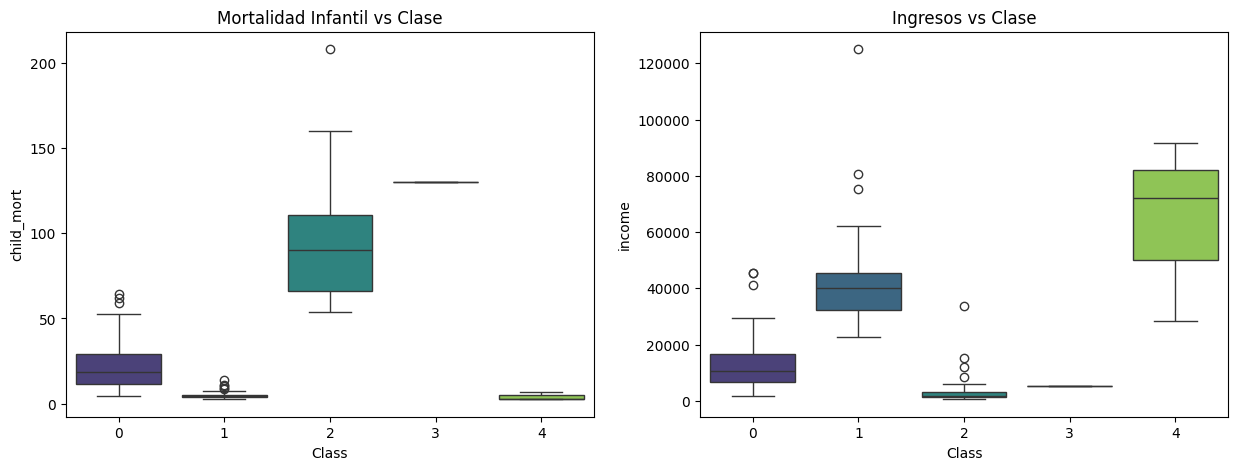

In [43]:
#  Box Plots (usando datos ORIGINALES)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (15,5))

plt.subplot(1,2,1)
sns.boxplot(x = 'Class', y = 'child_mort', data = data, palette='viridis'); 
plt.title('Mortalidad Infantil vs Clase')

plt.subplot(1,2,2)
sns.boxplot(x = 'Class', y = 'income', data = data, palette='viridis');
plt.title('Ingresos vs Clase')

plt.show()

In [44]:
# Visualización: Mapa

# Mapear las etiquetas numéricas a texto
label_map = {
    3: 'Might Need Help',
    4: 'Might Need Help',
    0: 'Might Need Help',
    1: 'No Help Needed',
    2: 'Help Needed'
}
scaled_df['Class_Label'] = scaled_df['Class'].map(label_map)

# Crear el mapa
fig = px.choropleth(
    scaled_df, 
    locationmode = 'country names',
    locations = 'Country',
    title = 'Clasificación de Países por Cluster (K-Means)',
    color = 'Class_Label', 
    color_discrete_map = {
        'Help Needed':'Red',
        'No Help Needed':'Green',
        'Might Need Help':'Yellow'
    }
)
fig.update_geos(fitbounds = "locations", visible = True)
fig.update_layout(legend_title_text = 'Clusters', legend_title_side = 'top')

# Configurar el renderizador para notebooks
pio.renderers.default = "notebook_connected"
fig.show()